In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/tmp/ipykernel_174492/1863898475.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
output_path_figures = os.path.join('output', 'figures', 'intro_questionnaire')
output_path_general = os.path.join('output')

In [3]:
# read survey structure
survey_structure = 'limesurvey_survey_748636.txt'
survey_overview = pd.read_csv(os.path.join('input', 'surveys', 'introduction', survey_structure), sep='\t')
survey_overview.head()

,id,related_id,class,type/scale,name,relevance,text,help,language,validation,...,time_limit_warning,time_limit_warning_2,time_limit_warning_2_display_time,time_limit_warning_2_message,time_limit_warning_2_style,time_limit_warning_display_time,time_limit_warning_message,time_limit_warning_style,use_dropdown,value_range_allows_missing
0,NaN,NaN,S,NaN,sid,NaN,748636,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,S,NaN,gsid,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,S,NaN,admin,NaN,inherit,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,S,NaN,adminemail,NaN,inherit,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,S,NaN,anonymized,NaN,N,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# read the survey data
survey_filename = 'results-survey748636-answercodes-binaryyesno.csv'
survey_responses = pd.read_csv(os.path.join('input', 'surveys', 'introduction', survey_filename), sep='\t')
print(survey_responses.head())

column_names = list(survey_responses.columns)
#question_codes = [(i, re.findall(r'\[.*?\]', i)) for i in column_names if i[0] == 'G']

# character to separate question code and description
qs_separator = '$'

parsed_column_names = []
for name in column_names:
    split_name = name.split(qs_separator)
    question_code = split_name[0] # separate question code from description text
    parsed_column_names.append([question_code, split_name[1]])

column_names_df = pd.DataFrame(data=parsed_column_names, columns=['questioncode', 'description'])

survey_responses.columns = column_names_df.loc[: , 'questioncode']
column_names_df = column_names_df.set_index('questioncode')
display(column_names_df)

display(survey_responses)

   id$Response ID submitdate$Date submitted  lastpage$Last page  \
0              27       2025-03-06 16:08:36                   2   
1              29       2025-03-07 22:31:14                   2   
2              30       2025-03-07 22:39:46                   2   
3              31       2025-03-08 20:43:24                   2   
4              32       2025-03-10 08:40:29                   2   

  startlanguage$Start language   seed$Seed startdate$Date started  \
0                           en   416765020    2025-03-06 16:05:22   
1                           en  1856894162    2025-03-07 22:26:10   
2                           en   472652592    2025-03-07 22:38:15   
3                           en  1917128786    2025-03-08 20:38:25   
4                           en  1286017166    2025-03-10 08:37:46   

  datestamp$Date last action  Q00$Please enter your age  \
0        2025-03-06 16:08:36                         26   
1        2025-03-07 22:31:14                         22   
2    

,description
questioncode,
id,Response ID
submitdate,Date submitted
lastpage,Last page
startlanguage,Start language
seed,Seed
startdate,Date started
datestamp,Date last action
Q00,Please enter your age
G01Q02,What gender do you identify as?


questioncode,id,submitdate,lastpage,startlanguage,seed,startdate,datestamp,Q00,G01Q02,G01Q02[other],...,G01Q17Time,G01Q18Time,groupTime421,G02Q05Time,G02Q08Time,G02Q11Time,G02Q12Time,G02Q13Time,G02Q14Time,G02Q06Time
0,27,2025-03-06 16:08:36,2,en,416765020,2025-03-06 16:05:22,2025-03-06 16:08:36,26,AO02,NaN,...,NaN,NaN,145.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29,2025-03-07 22:31:14,2,en,1856894162,2025-03-07 22:26:10,2025-03-07 22:31:14,22,AO01,NaN,...,NaN,NaN,218.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30,2025-03-07 22:39:46,2,en,472652592,2025-03-07 22:38:15,2025-03-07 22:39:46,22,AO02,NaN,...,NaN,NaN,65.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31,2025-03-08 20:43:24,2,en,1917128786,2025-03-08 20:38:25,2025-03-08 20:43:24,27,AO01,NaN,...,NaN,NaN,181.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,32,2025-03-10 08:40:29,2,en,1286017166,2025-03-10 08:37:46,2025-03-10 08:40:29,25,AO01,NaN,...,NaN,NaN,137.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,33,2025-03-10 09:02:09,2,en,146641093,2025-03-10 09:00:54,2025-03-10 09:02:09,25,AO02,NaN,...,NaN,NaN,46.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,35,2025-03-14 16:01:07,2,en,739482389,2025-03-14 15:58:08,2025-03-14 16:01:07,37,AO02,NaN,...,NaN,NaN,136.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,36,2025-03-14 16:00:38,2,en,416876241,2025-03-14 15:58:24,2025-03-14 16:00:38,29,AO02,NaN,...,NaN,NaN,100.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,37,2025-03-14 16:00:57,2,en,1433037681,2025-03-14 15:58:25,2025-03-14 16:00:57,30,AO02,NaN,...,NaN,NaN,92.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,39,2025-03-15 20:41:04,2,en,433912131,2025-03-15 20:37:38,2025-03-15 20:41:04,25,AO02,NaN,...,NaN,NaN,172.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# remove test participants
print(survey_responses["id"])

def remove_participant(df, participant_id, col = 'participant_id'):
    entries = df[df[col] == participant_id]
    return df.drop(entries.index)

def remove_participant_not_in(df, list, col = 'id'):
    entries = df[~df[col].isin(list)]
    return df.drop(entries.index)

    
tokens = ["6573f86e-0207-4286-b036-a83f25a630c3", "ecc027d0-42cd-42a1-bc2e-990b5516565b", "a5bbafd1-4ef0-49e4-95bd-65170953633c", "2aac5afe-a3af-4135-a1a3-78adf87ae9d8", "93f70a37-e7d5-4bcf-adbc-d106ca47c27b", "04e5a551-66df-49db-a8ad-3eff1dbde36b", "b800fdfb-797e-4e6d-81ca-8c0ec36094b2", "7d1fcfca-d63f-45e6-a0cf-06122aebe7c6", "3971c458-2966-43ed-a759-067def1cc6ee", "5b6b66f7-99db-48a1-b61a-0eaf97a1c8fc", "4860412b-df67-453f-946e-981b311bcb69", "3b49f849-3081-4478-81ce-d65450662c47", "ee4fc4b9-7b40-4acc-8299-bf6e2da559f9", "ee84f721-81d3-4914-b1a4-09de1502b0bc", "024d811b-6640-4745-b751-39582d07e3ea", "e24dd41b-25cb-4503-a4b7-4919fc0e688f", "5c811b7f-e3a9-4b77-bb08-043f8d743026", "46820311-be03-4d2e-b993-90ac3bec3c92", "5a6b1f2c-f401-420f-b26d-46d9db679384", "14291cb8-c3c7-433e-9a0c-830cca8e4422","a1f051f1-f2f3-45e1-9274-7deb05f97604", "20d63649-2146-4c8e-8861-14a647fdcd13", "38811499-e7ca-453e-a57b-86c5dcdee514", "5d9124de-67e0-4bd1-80e6-ec33aa775d1a", "b7d11063-8fd9-4d87-b9c4-afa680ba7235", "63e04882-b933-435f-b84b-7a638b9c5ae8", "c112a2c5-0f9e-4a7a-a711-74160720c17d", "191d2035-c072-40fa-9639-60a190a01598", "3f2377a6-c572-44fe-b4ae-44be004fa5da", "41b03f59-088a-4ca7-b174-44980d1d8d78"]

# remove participants that are not in the tokens list
survey_responses = (remove_participant_not_in(survey_responses, tokens, "G01Q17")) # participant_token column

display(survey_responses)

0     27
1     29
2     30
3     31
4     32
5     33
6     35
7     36
8     37
9     39
10    40
11    41
12    42
13    54
14    55
15    56
16    57
17    58
18    59
19    60
20    61
21    62
22    63
23    65
24    66
25    68
26    69
27    70
28    71
29    72
30    73
31    76
32    78
Name: id, dtype: int64


questioncode,id,submitdate,lastpage,startlanguage,seed,startdate,datestamp,Q00,G01Q02,G01Q02[other],...,G01Q17Time,G01Q18Time,groupTime421,G02Q05Time,G02Q08Time,G02Q11Time,G02Q12Time,G02Q13Time,G02Q14Time,G02Q06Time
0,27,2025-03-06 16:08:36,2,en,416765020,2025-03-06 16:05:22,2025-03-06 16:08:36,26,AO02,NaN,...,NaN,NaN,145.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29,2025-03-07 22:31:14,2,en,1856894162,2025-03-07 22:26:10,2025-03-07 22:31:14,22,AO01,NaN,...,NaN,NaN,218.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30,2025-03-07 22:39:46,2,en,472652592,2025-03-07 22:38:15,2025-03-07 22:39:46,22,AO02,NaN,...,NaN,NaN,65.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,31,2025-03-08 20:43:24,2,en,1917128786,2025-03-08 20:38:25,2025-03-08 20:43:24,27,AO01,NaN,...,NaN,NaN,181.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,32,2025-03-10 08:40:29,2,en,1286017166,2025-03-10 08:37:46,2025-03-10 08:40:29,25,AO01,NaN,...,NaN,NaN,137.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,33,2025-03-10 09:02:09,2,en,146641093,2025-03-10 09:00:54,2025-03-10 09:02:09,25,AO02,NaN,...,NaN,NaN,46.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,35,2025-03-14 16:01:07,2,en,739482389,2025-03-14 15:58:08,2025-03-14 16:01:07,37,AO02,NaN,...,NaN,NaN,136.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,36,2025-03-14 16:00:38,2,en,416876241,2025-03-14 15:58:24,2025-03-14 16:00:38,29,AO02,NaN,...,NaN,NaN,100.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,37,2025-03-14 16:00:57,2,en,1433037681,2025-03-14 15:58:25,2025-03-14 16:00:57,30,AO02,NaN,...,NaN,NaN,92.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,39,2025-03-15 20:41:04,2,en,433912131,2025-03-15 20:37:38,2025-03-15 20:41:04,25,AO02,NaN,...,NaN,NaN,172.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Map answer codes to options

#rating
rating_data = [
    ['AO01', 'strongly_disagree', 1, 'Strongly Disagree'],
    ['AO02', 'disagree', 2, 'Disagree'],
    ['AO03', 'neutral', 3, 'Neutral'],
    ['AO04', 'agree', 4, 'Agree'],
    ['AO05', 'strongly_agree', 5, 'Strongly Agree'],
]
rating = pd.DataFrame(data=rating_data, columns=['answer_code', 'option', 'value', 'label'])

#gender identification
gender_data = [
    ['AO01', 'female', 1, 'Female'],
    ['AO02', 'male', 2, 'Male'],
    ['AO03', 'non_binary', 3, 'Non-Binary'],
    ['AO04', 'prefer_not_to_disclose', 3, 'Prefer Not To Disclose'],
]
gender = pd.DataFrame(data=gender_data, columns=['answer_code', 'option', 'value', 'label'])

#language data
language_data = [
    ['AO01', 'no_knowledge_of_english', 1, 'No knowledge of English'],
    ['AO02', 'speak_poorly', 2, 'Speak Poorly'],
    ['AO03', 'fairly_well', 3, 'Fairly Well'],
    ['AO04', 'well', 4, 'Well'],
    ['AO05', 'very_well', 5, 'Very Well'],
    ['AO06', 'native_speaker', 6, 'Native Speaker'],
]
language = pd.DataFrame(data=language_data, columns=['answer_code', 'option', 'value', 'label'])

#frequency
frequency_data = [
    ['AO01', 'daily', 'Daily'],
    ['AO02', 'weekly', 'Weekly'],
    ['AO03', 'monthly', 'Monthly'],
    ['AO04', 'less_than_monthly', 'Less than monthly'],
    ['AO05', 'never', 'Never']
]
frequency = pd.DataFrame(data=frequency_data, columns=['answer_code', 'option', 'label'])


In [7]:
# select interesting columns from introduction survey
q11_columns = ["G02Q11[SQ001]", "G02Q11[SQ002]", "G02Q11[SQ003]", "G02Q11[SQ004]", "G02Q11[SQ005]"] # question 11
q13_columns = ["G02Q13[SQ001]", "G02Q13[SQ002]", "G02Q13[SQ003]", "G02Q13[SQ004]", "G02Q13[SQ005]", "G02Q13[SQ006]"] # question 13
q14_columns = ["G02Q14[SQ001]", "G02Q14[SQ002]", "G02Q14[SQ003]", "G02Q14[SQ004]", "G02Q14[SQ005]", "G02Q14[SQ006]", "G02Q14[SQ007]", "G02Q14[SQ008]"] # question 14

q11_options = {
    "SQ001": "LibreOffice / OpenOffice", 
    "SQ002": "Google Docs", 
    "SQ003": "Microsoft Office", 
    "SQ004": "Apple Pages", 
    "SQ005": "Another tool"
}

q13_options = {
    "SQ001": "Google Docs", 
    "SQ002": "Microsoft Office", 
    "SQ003": "Dropbox Paper", 
    "SQ004": "Etherpad", 
    "SQ005": "Overleaf", 
    "SQ006": "Another tool"
}

q14_options = {
    "SQ001": "Email", 
    "SQ002": "Chat (e.g. Slack, Mattermost, Teams)", 
    "SQ003": "Voice Calls", 
    "SQ004": "Video Calls", 
    "SQ005": "In-Person Meetings", 
    "SQ006": "Document Chat", 
    "SQ007": "Interactive Comments in a Document", 
    "SQ008": "Inline text annotations"
}

q11_q13_replies = {"Yes": 1, "No": 0}


In [8]:
#declaring the questions here, any other questions are free text questions

frequency_questions = ['G02Q12', 'G02Q05', 'G02Q06', 'G02Q14']

age_question = 'Q00'

gender_question = 'G01Q02'

profession_question = 'G01Q03'

language_questions = ['G01Q04']

free_form_questions = ['G02Q08']

In [9]:
# taken and adapted from: https://matplotlib.org/stable/gallery/lines_bars_and_markers/horizontal_barchart_distribution.html
def survey(results, category_names, split_labels = False, title_override = None, x_len = 121, step = 10):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    split_labels : bool
        Indicator if title should be derived from labels and shorten labels
    """
    labels = list(results.keys())
    category_names = [c.replace("_", " ") for c in category_names]
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    category_colors = plt.colormaps['Blues_r'](np.linspace(0.15, 0.85, len(category_names)))

    display(data)

    height = 0.6 * len(results)

    fig, ax = plt.subplots(figsize=(10, height))
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    
    x_max = np.sum(data, axis=1).max()
    ax.set_xlim(0, x_max)
    
    ax.set_xticks(np.arange(0, x_max + x_max / 4, x_max / 4))
    ax.set_xticklabels(labels=["0%", "25%", "50%", "75%", "100%"])

    # 5% padding on the y-axis and none on the x-axis
    ax.margins(None, 0.05)

    ax.tick_params(axis='y', which='both', length=0)

    if split_labels:
        title = labels[0].split(" [")
        ax.set_title(title[0], pad=10)
        for i, label in enumerate(labels):
            labels[i] = label.split(" [")[1][:-1]
            
    if title_override is not None:
        ax.set_title(title_override, pad=10)

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.6,
                        label=colname, color=color)

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'dimgrey'
        ax.bar_label(rects, label_type='center', color=text_color, fmt=lambda x: int(x) if x > 0 else '')

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=False, shadow=False, ncol=5)

    return fig, ax

In [10]:
number_of_participants = survey_responses[age_question].size
print("Number of participants:", number_of_participants)

Number of participants: 30


In [11]:
# frequency fix (if a frequency question has answer codes)
replace_codes = {'AO02': 'AO03', 'AO03': 'AO02'} #replaces answer code 03 with 02 and vice versa
survey_responses['G02Q05'] = survey_responses['G02Q05'].replace({'AO02': 'AO03', 'AO03': 'AO02'})

array([[16, 10,  3,  1,  0],
       [20,  6,  3,  0,  1],
       [ 1, 13,  7,  9,  0],
       [10,  2,  7,  5,  6],
       [16,  6,  4,  4,  0],
       [ 6,  5,  5,  6,  8],
       [ 6,  8,  8,  2,  6],
       [ 6,  8,  9,  4,  3],
       [ 2,  5,  3,  5, 15],
       [ 1,  8, 10,  7,  4],
       [ 1,  8,  7,  6,  8]])

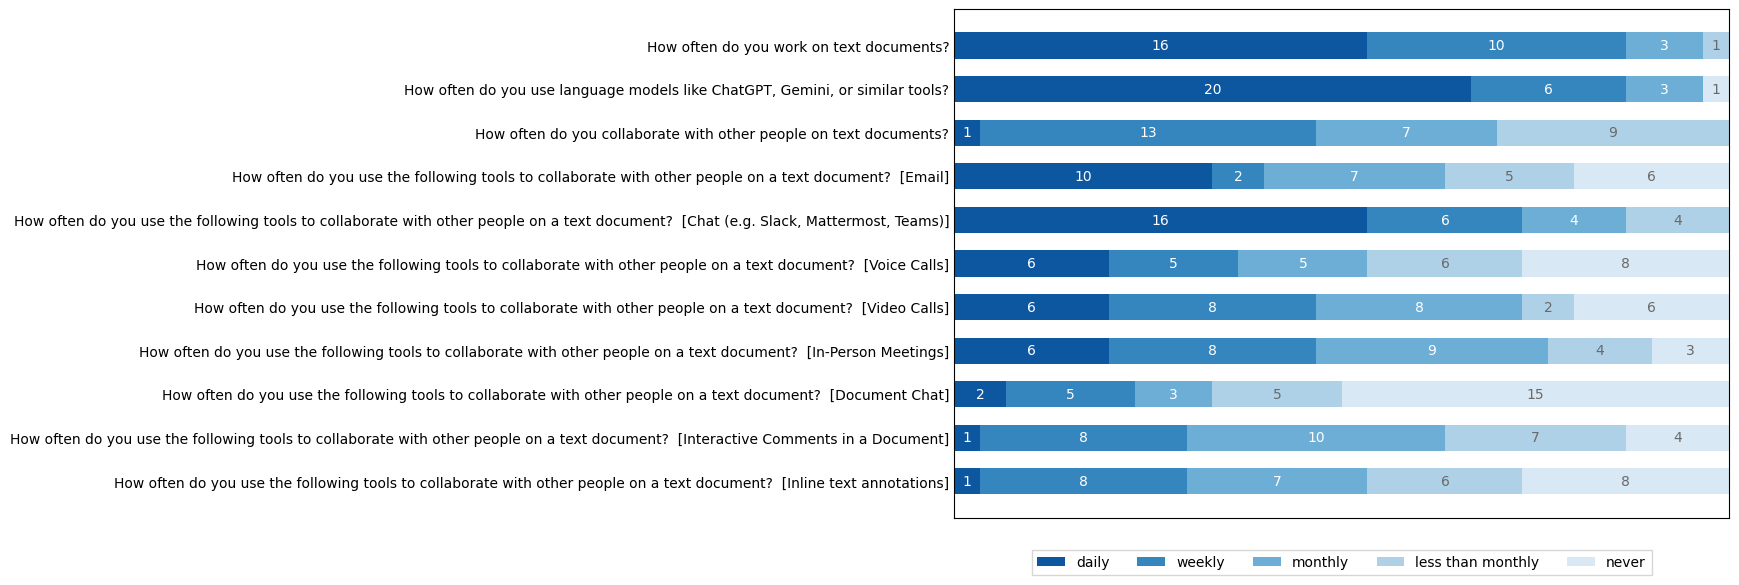

In [12]:
# frequency columns overview

frequency_cols = [col for col in survey_responses if col.startswith(tuple(frequency_questions))]

df_frequencies = survey_responses[frequency_cols]
df_frequencies = df_frequencies.replace(list(frequency['answer_code']), list(frequency['option']))
melted = pd.melt(df_frequencies)
counts = pd.crosstab(index=[melted['value']], columns=[melted['questioncode']]).transpose()

# if a frequency option has not been selected, add a column with 0s
frequency_options = list(frequency['option'])
for f_option in frequency_options:
  if not f_option in counts:
    counts[f_option] = 0

counts_freq = counts[frequency_options]

mapping = column_names_df['description'].to_dict()
#display(counts.index)

counts = counts_freq.rename(index=mapping)

colors = plt.colormaps['Blues_r'](np.linspace(0.15, 0.85, 5))

# with counts in bars
results = counts.T.to_dict('list')
survey(results, list(frequency['option']))
plt.savefig(os.path.join(output_path_figures, 'frequency_overview.pdf'), bbox_inches='tight')


In [13]:
def get_percentages(df):
    percentages = df.div(df.sum(axis=1), axis=0)
    percentages = percentages.mul(100, axis=0)
    return percentages

value,daily,weekly,monthly,less_than_monthly,never
questioncode,,,,,
G02Q12,1,13,7,9,0
G02Q05,16,10,3,1,0
G02Q06,20,6,3,0,1


value,daily,weekly,monthly,less_than_monthly,never
questioncode,,,,,
G02Q12,3.333333,43.333333,23.333333,30.000000,0.000000
G02Q05,53.333333,33.333333,10.000000,3.333333,0.000000
G02Q06,66.666667,20.000000,10.000000,0.000000,3.333333


{'How often do you collaborate with other people on text documents?': [1,
  13,
  7,
  9,
  0],
 'How often do you work on text documents?': [16, 10, 3, 1, 0],
 'How often do you use language models like ChatGPT, Gemini, or similar tools?': [20,
  6,
  3,
  0,
  1]}

array([[ 1, 13,  7,  9,  0],
       [16, 10,  3,  1,  0],
       [20,  6,  3,  0,  1]])

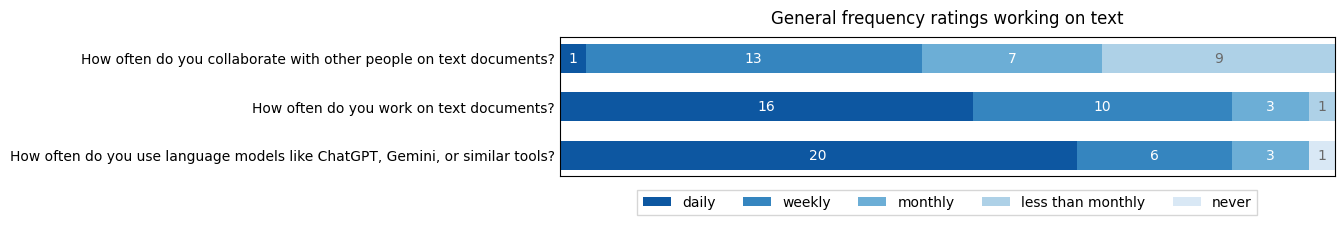

value,daily,weekly,monthly,less_than_monthly,never
questioncode,,,,,
G02Q14[SQ001],10,2,7,5,6
G02Q14[SQ002],16,6,4,4,0
G02Q14[SQ003],6,5,5,6,8
G02Q14[SQ004],6,8,8,2,6
G02Q14[SQ005],6,8,9,4,3
G02Q14[SQ006],2,5,3,5,15
G02Q14[SQ007],1,8,10,7,4
G02Q14[SQ008],1,8,7,6,8


value,daily,weekly,monthly,less_than_monthly,never
questioncode,,,,,
G02Q14[SQ001],33.333333,6.666667,23.333333,16.666667,20.000000
G02Q14[SQ002],53.333333,20.000000,13.333333,13.333333,0.000000
G02Q14[SQ003],20.000000,16.666667,16.666667,20.000000,26.666667
G02Q14[SQ004],20.000000,26.666667,26.666667,6.666667,20.000000
G02Q14[SQ005],20.000000,26.666667,30.000000,13.333333,10.000000
G02Q14[SQ006],6.666667,16.666667,10.000000,16.666667,50.000000
G02Q14[SQ007],3.333333,26.666667,33.333333,23.333333,13.333333
G02Q14[SQ008],3.333333,26.666667,23.333333,20.000000,26.666667


{'How often do you use the following tools to collaborate with other people on a text document?  [Email]': [10,
  2,
  7,
  5,
  6],
 'How often do you use the following tools to collaborate with other people on a text document?  [Chat (e.g. Slack, Mattermost, Teams)]': [16,
  6,
  4,
  4,
  0],
 'How often do you use the following tools to collaborate with other people on a text document?  [Voice Calls]': [6,
  5,
  5,
  6,
  8],
 'How often do you use the following tools to collaborate with other people on a text document?  [Video Calls]': [6,
  8,
  8,
  2,
  6],
 'How often do you use the following tools to collaborate with other people on a text document?  [In-Person Meetings]': [6,
  8,
  9,
  4,
  3],
 'How often do you use the following tools to collaborate with other people on a text document?  [Document Chat]': [2,
  5,
  3,
  5,
  15],
 'How often do you use the following tools to collaborate with other people on a text document?  [Interactive Comments in a Document]': [1,
 

array([[10,  2,  7,  5,  6],
       [16,  6,  4,  4,  0],
       [ 6,  5,  5,  6,  8],
       [ 6,  8,  8,  2,  6],
       [ 6,  8,  9,  4,  3],
       [ 2,  5,  3,  5, 15],
       [ 1,  8, 10,  7,  4],
       [ 1,  8,  7,  6,  8]])

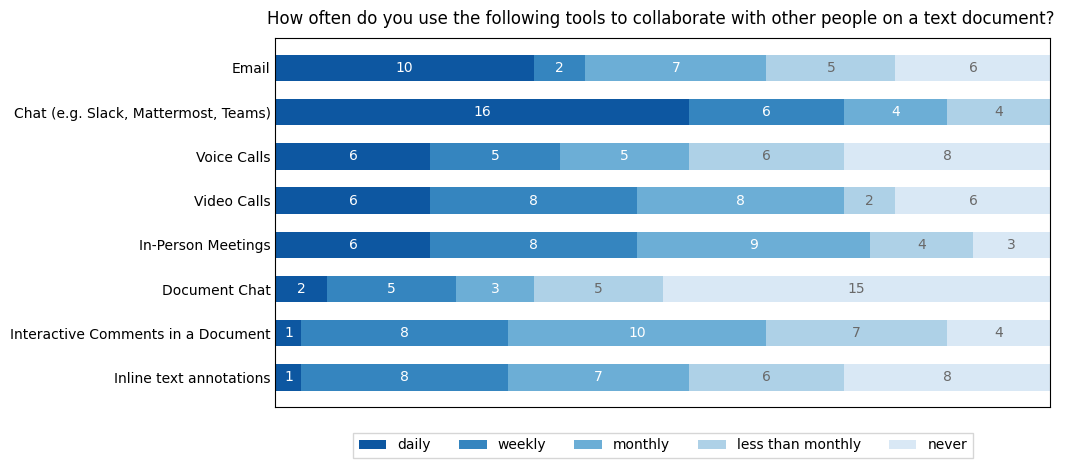

In [14]:
# frequency sub graphs
frequency_sub_general = ['G02Q12', 'G02Q05', 'G02Q06']
frequency_sub_collaboration = ['G02Q14[SQ001]', 'G02Q14[SQ002]', 'G02Q14[SQ003]', 'G02Q14[SQ004]', 'G02Q14[SQ005]', 'G02Q14[SQ006]', 'G02Q14[SQ007]', 'G02Q14[SQ008]']

frequency_subs = {
    "frequency_sub_general": frequency_sub_general, # General ratings on usage frequencies working on text
    "frequency_sub_collaboration": frequency_sub_collaboration
}

for key, freq_sub in frequency_subs.items():
    # get counts for subquestions listed above
    counts_freq_sub = counts_freq.loc[freq_sub,:]
    display(counts_freq_sub)
    percentages = get_percentages(counts_freq_sub)
    display(percentages)
    # replace codes through questions
    counts_freq_sub= counts_freq_sub.rename(index=mapping)
    colors = plt.colormaps['Blues_r'](np.linspace(0.15, 0.85, 5))

    # plot with counts in bars
    results = counts_freq_sub.T.to_dict('list')
    title_override = "General frequency ratings working on text" if freq_sub is frequency_sub_general else None
    display(results)
    survey(results, list(frequency['option']), freq_sub is not frequency_sub_general, title_override)

    plt.savefig(os.path.join(output_path_figures, key + '.pdf'), bbox_inches='tight')


    plt.show()

In [15]:
# map the results
def map_value(key: str, options: dict[str, str]) -> str:
    for k, v in options.items():
        if k in key:
            return v
    
    assert False, "Key not found"

questioncode
G02Q11[SQ001]     1
G02Q11[SQ002]    22
G02Q11[SQ003]    20
G02Q11[SQ004]     3
G02Q11[SQ005]    13
dtype: int64
Index(['G02Q11[SQ001]', 'G02Q11[SQ002]', 'G02Q11[SQ003]', 'G02Q11[SQ004]',
       'G02Q11[SQ005]'],
      dtype='object', name='questioncode')
Q11 Percentages (sum yes responses / number_of_participants)
questioncode
LibreOffice / OpenOffice     3.333333
Apple Pages                 10.000000
Another tool                43.333333
Microsoft Office            66.666667
Google Docs                 73.333333
dtype: float64
Q13 Percentages (sum yes responses / number_of_participants)
questioncode
Dropbox Paper        6.666667
Etherpad             3.333333
Overleaf            50.000000
Another tool        13.333333
Microsoft Office    40.000000
Google Docs         76.666667
dtype: float64


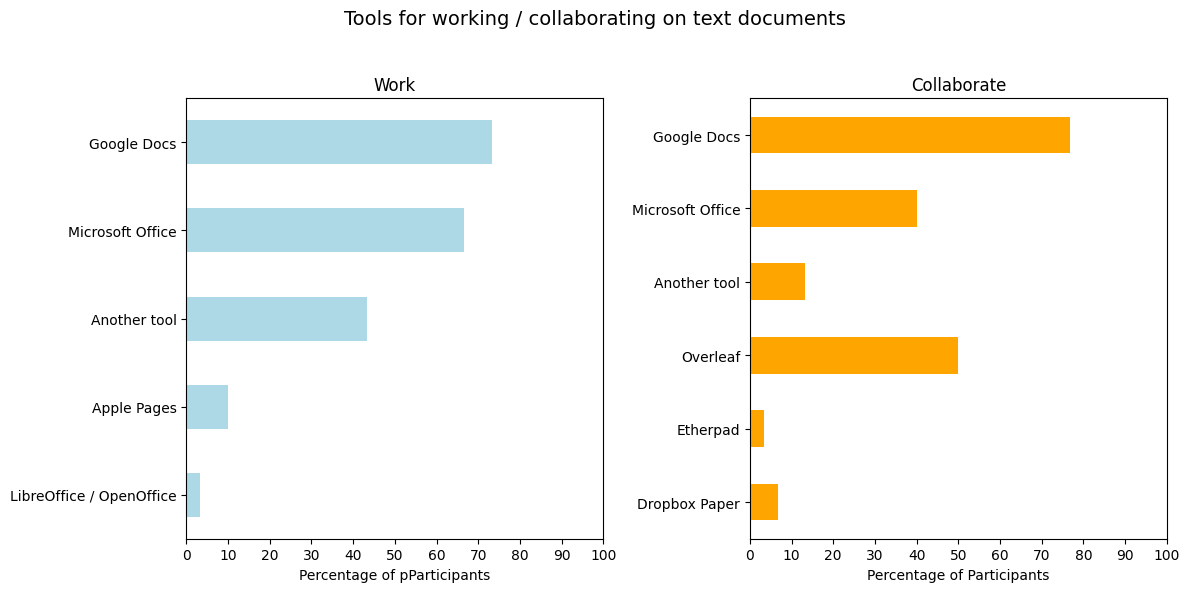

<Figure size 640x480 with 0 Axes>

In [16]:
# --- Q11 ---
responses_q11 = survey_responses[q11_columns].copy()
responses_q11 = responses_q11.sum(axis=0)
print(responses_q11)
print(responses_q11.index)
responses_q11.index = responses_q11.index.map(lambda key: map_value(key, q11_options))

# --- Q13 ---
responses_q13 = survey_responses[q13_columns].copy()
responses_q13 = responses_q13.sum(axis=0)
responses_q13.index = responses_q13.index.map(lambda key: map_value(key, q13_options))


priorities = {
    "Google Docs": 0,
    "Microsoft Office": 1,
    "Another tool": 2,
}

q11_labels = sorted(
    responses_q11.index,
    key=lambda label: priorities.get(label, 999),
    reverse=True,
)

q13_labels = sorted(
    responses_q13.index,
    key=lambda label: priorities.get(label, 999),
    reverse=True,
)
# Reindex both responses with sorted labels
responses_q11 = responses_q11.reindex(q11_labels, fill_value=0)
responses_q13 = responses_q13.reindex(q13_labels, fill_value=0)

responses_q11= responses_q11.div(number_of_participants, axis=0).mul(100, axis=0)
responses_q13= responses_q13.div(number_of_participants, axis=0).mul(100, axis=0)

print("Q11 Percentages (sum yes responses / number_of_participants)")
print(responses_q11)
print("Q13 Percentages (sum yes responses / number_of_participants)")
print(responses_q13)

# --- Plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharex=True)

responses_q11.plot(kind='barh', color='lightblue', ax=axes[0], title="Work")
axes[0].set_xlabel("Percentage of pParticipants")
axes[0].set_ylabel("")
axes[0].set_xticks(np.arange(0, 110, 10))
axes[0].set_xlim(0, 100)

responses_q13.plot(kind='barh', color='orange', ax=axes[1], title="Collaborate")
axes[1].set_xlabel("Percentage of Participants")
axes[1].set_ylabel("")  # cleaner layout
axes[1].set_xticks(np.arange(0, 110, 10))
axes[1].set_xlim(0, 100)

# Shared title
fig.suptitle("Tools for working / collaborating on text documents", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
plt.savefig(os.path.join(output_path_figures, 'tool_usage.pdf'), bbox_inches='tight')

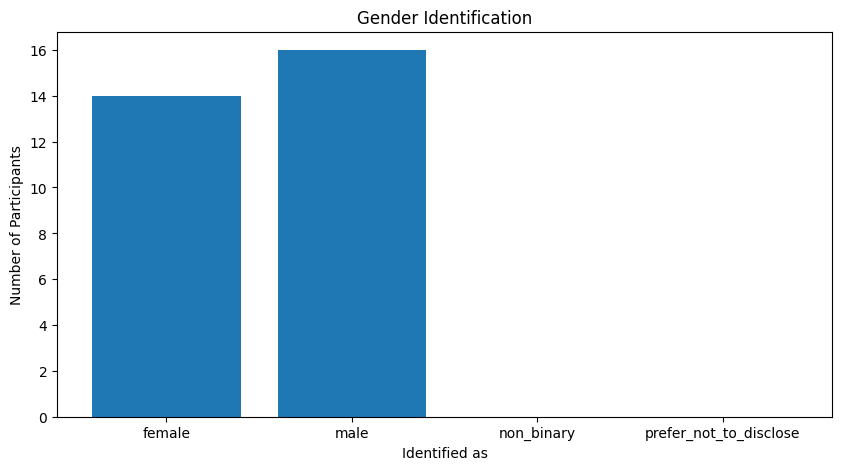

In [17]:
# gender

df_gender = survey_responses[gender_question]
df_gender = df_gender.replace(list(gender['answer_code']), list(gender['option']))

counts = df_gender.groupby(df_gender).count()

final_counts = {}
for option in gender['option']:
    if option in counts:
        final_counts[option] = counts[option]
    else:
        final_counts[option] = 0

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = [i for i, _ in enumerate(gender['option'])]

ax.bar(x_pos, list(final_counts.values()))

plt.xlabel("Identified as")
plt.ylabel("Number of Participants")
plt.title("Gender Identification")

plt.xticks(x_pos, gender['option'])

plt.show()

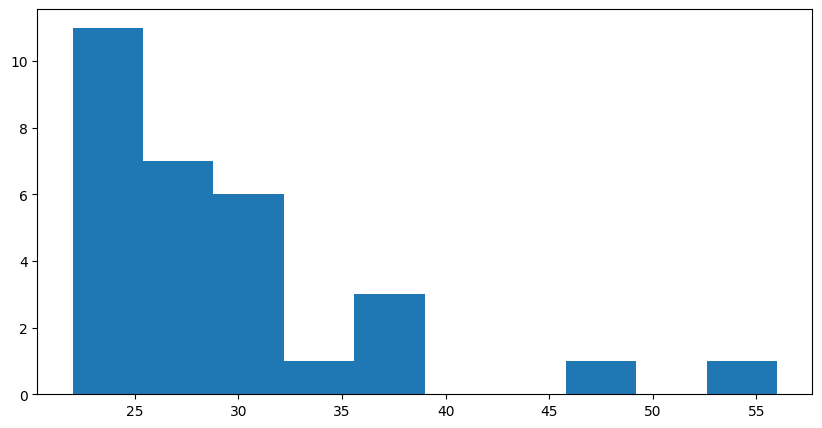

In [18]:
# age

age = survey_responses[age_question]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(age)

plt.show()

{'no_knowledge_of_english': 0,
 'speak_poorly': 0,
 'fairly_well': 1,
 'well': 8,
 'very_well': 19,
 'native_speaker': 2}

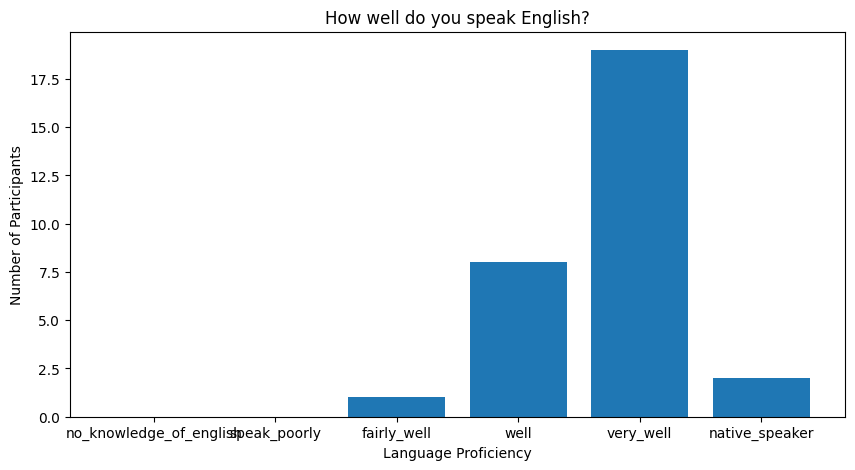

In [19]:
# language

for language_question in language_questions:

    df_language = survey_responses[language_question]
    df_language = df_language.replace(list(language['answer_code']), list(language['option']))

    counts = df_language.groupby(df_language).count()

    fig, ax = plt.subplots(figsize=(10, 5))

    final_counts = {}
    for option in language['option']:
        if option in counts:
            final_counts[option] = counts[option]
        else:
            final_counts[option] = 0

    x_pos = [i for i, _ in enumerate(language['option'])]

    display(final_counts)

    ax.bar(x_pos, list(final_counts.values()))

    title =column_names_df.loc[language_question]['description']

    plt.xlabel("Language Proficiency")
    plt.ylabel("Number of Participants")
    plt.title(title)

    plt.xticks(x_pos, language['option'])

    plt.show()

In [20]:
# extract free text repsonses

df_occupation = survey_responses[profession_question]
display(df_occupation)

df_occupation.to_csv(os.path.join(output_path_general, 'intro_profession_responses.csv'))

0                           Computer Science Student
1                                    Working Student
2                                  Software engineer
3                                            Student
4                                            Student
5                                  Software Engineer
6                                            Postdoc
7                                 Research Associate
8     Computer Scientist (Computational Interaction)
9                                 Student/translator
10                                           Student
11               Bachelor Student (Computer Science)
12                                        Journalist
13                                        Researcher
15                                               HCI
16                                           Student
17                                           Student
18                           Postdoctoral Researcher
20                                           S

In [21]:
# extract free text repsonses

free_form_cols = [col for col in survey_responses if col.startswith(tuple(free_form_questions))]
df_free_form = survey_responses[free_form_cols]
display(df_free_form)

df_free_form.to_csv(os.path.join(output_path_general, 'intro_free_form_responses.csv'))

questioncode,G02Q08,G02Q08Time
0,"Studying, Writing reports",NaN
1,studying & working,NaN
2,"Free time, working, studying",NaN
3,NaN,NaN
4,"studying, research, journalism",NaN
5,NaN,NaN
6,"paper writing, scientific proposals",NaN
7,Paper writing,NaN
8,Paper writing,NaN
9,"Translation, studying, essays writing, story w...",NaN
